# AthleteIQ — Injury Prediction Model: Build Path
This notebook trains an XGBoost injury risk model using historical athlete session load and wellness data to replace hand-written ACWR thresholds in AthleteIQ.

---

## 01. Problem Statement
Traditional injury prevention models rely on simple static thresholds (e.g., ACWR > 1.5 is danger, ACWR < 0.8 is undertraining). However, athletes have unique baseline profiles, and injuries are caused by a combination of fatigue, recovery levels, monotony, and sudden spikes. 

This notebook transitions AthleteIQ from a rule-based risk calculation to a machine learning-driven model using XGBoost and SHAP explainability. This allows coaches to see not only the risk score but also the precise factors contributing to it.

In [1]:
# Standard Libraries
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap

# Import custom helper modules
sys.path.append(os.path.abspath('../src'))
import features
import evaluate

print("Libraries imported successfully.")

Libraries imported successfully.


## 02. Dataset

This model is trained on **synthetic time-series data** that mirrors exactly what AthleteIQ collects in production: daily RPE × duration session loads and wellness check-ins, per athlete.

**Why synthetic:** Public injury datasets are either cross-sectional (one row per athlete, no time dimension) or use features AthleteIQ does not collect. To build a model that can actually be deployed into AthleteIQ, the training features must match the production features. The generator (`ml/src/synthetic.py`) creates realistic daily logs where injury risk is **causally driven** by sports-science signals — ACWR, training monotony, load spikes, poor wellness, and consecutive high-intensity days.

**The roadmap:** Once AthleteIQ accumulates 6+ months of real academy data, the same pipeline retrains on production data with zero feature changes. The synthetic model is the bootstrap.

- Generator: `ml/src/synthetic.py`
- Reproducible end-to-end training script: `ml/src/train.py`

In [2]:
# Generate synthetic daily training-load data (mirrors AthleteIQ production schema)
import synthetic

df = synthetic.generate_synthetic_data(n_athletes=40, n_days=365, seed=42)

print(f"Dataset shape: {df.shape}")
print(f"Athletes: {df['athlete_id'].nunique()} | Days per athlete: {df.groupby('athlete_id').size().iloc[0]}")
print(f"Daily injury rate: {df['injured'].mean()*100:.2f}%  ({int(df['injured'].sum())} injury-days)")
df.head()

Dataset shape: (14600, 7)
Athletes: 40 | Days per athlete: 365
Daily injury rate: 4.05%  (591 injury-days)


,athlete_id,date,rpe,duration,session_load,wellness,injured
0,A001,2025-01-01,3,40,120,9.0,0
1,A001,2025-01-02,5,73,365,9.4,0
2,A001,2025-01-03,7,47,329,8.8,0
3,A001,2025-01-04,6,57,342,7.5,0
4,A001,2025-01-05,5,68,340,8.2,0


## 03. Feature Engineering
We use our custom `features.py` module to engineer 11 player workload and recovery features:
- `acute_load` (7-day total load)
- `chronic_load` (28-day average load)
- `acwr` (acute-to-chronic workload ratio)
- `monotony` (daily load variation)
- `strain` (fatigue signal)
- `load_spike` (this week total vs last week total)
- `consecutive_high_days` (back-to-back heavy days)
- `days_since_rest` (recovery indicator)
- `wellness_trend` (7-day rolling wellness score)
- `days_since_last_injury` (re-injury risk profile)

In [3]:
# Run feature engineering from our local ml/src/features.py module
df_engineered = features.engineer_all_features(df)

# Target: 1 if the athlete is injured on ANY of the next 7 days (T+1 .. T+7).
# NOTE: this is a forward *window*, not a single day. Using shift(-7) would label
# only the exact 7th day ahead, which is nearly unpredictable from today's load.
def forward_7d_injury(s):
    a = s.values
    out = np.zeros(len(a), dtype=int)
    for i in range(len(a)):
        window = a[i + 1:i + 8]
        out[i] = 1 if (window.size and window.max() > 0) else 0
    return pd.Series(out, index=s.index)

df_engineered['injury_next_7_days'] = (
    df_engineered.groupby('athlete_id')['injured'].transform(forward_7d_injury)
)
df_engineered = df_engineered.dropna(subset=['acwr'])

# Features columns to train on (11 engineered signals)
feature_cols = [
    'session_load', 'acute_load', 'chronic_load', 'acwr', 'monotony',
    'strain', 'load_spike', 'consecutive_high_days', 'days_since_rest',
    'wellness_trend', 'days_since_last_injury'
]

print(f"Target rate (injury within 7 days): {df_engineered['injury_next_7_days'].mean()*100:.1f}%")
df_engineered[feature_cols + ['injury_next_7_days']].tail()

Target rate (injury within 7 days): 25.9%


,session_load,acute_load,chronic_load,acwr,monotony,strain,load_spike,consecutive_high_days,days_since_rest,wellness_trend,days_since_last_injury,injury_next_7_days
14595,504,2413.0,350.392857,0.983794,1.674063,4039.513296,1.063464,0,6,7.257143,14,0
14596,0,2413.0,350.392857,0.983794,1.674063,4039.513296,1.063464,0,0,7.257143,15,0
14597,285,2338.0,343.857143,0.971334,1.614029,3773.599535,0.889312,0,1,7.271429,16,0
14598,399,2489.0,352.000000,1.010146,1.740178,4331.302937,0.865137,0,2,7.085714,17,0
14599,310,2483.0,336.321429,1.054688,1.734233,4306.101640,1.087604,0,3,6.771429,18,0


## 04. Exploratory Data Analysis (EDA)
Before training, we plot the relationships between features and injury rates to validate the signals.

/var/folders/hc/hk1fn3mj6px3gw3n3jdt_md00000gn/T/ipykernel_2297/2361314462.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_by_zone.index, y=injury_by_zone.values, palette='OrRd')


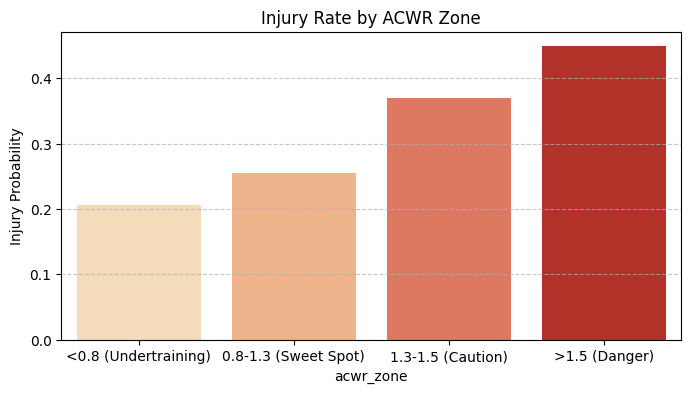

In [4]:
# 1. Plot Injury Rate by ACWR zone
df_engineered['acwr_zone'] = pd.cut(df_engineered['acwr'], bins=[-1, 0.8, 1.3, 1.5, 10.0], labels=['<0.8 (Undertraining)', '0.8-1.3 (Sweet Spot)', '1.3-1.5 (Caution)', '>1.5 (Danger)'])
injury_by_zone = df_engineered.groupby('acwr_zone', observed=False)['injury_next_7_days'].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=injury_by_zone.index, y=injury_by_zone.values, palette='OrRd')
plt.title('Injury Rate by ACWR Zone')
plt.ylabel('Injury Probability')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

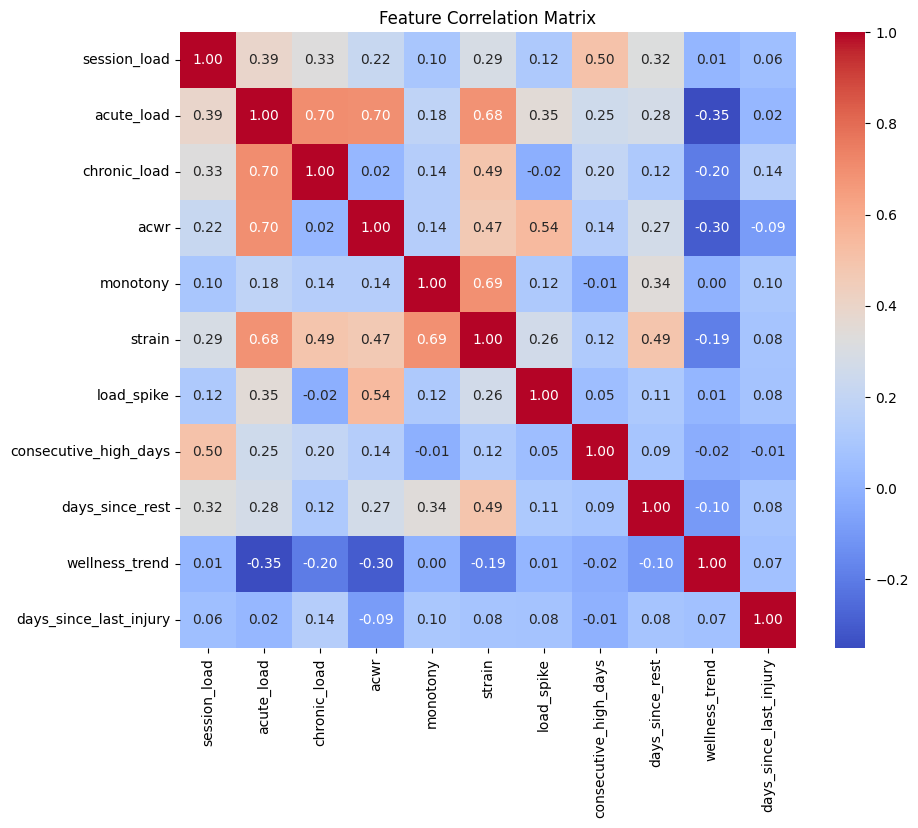

In [5]:
# 2. Correlation matrix of all features
plt.figure(figsize=(10, 8))
sns.heatmap(df_engineered[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.show()

## 05. Train/Test Split
For sports workload data, a random split leaks future context into the past. We use temporal splitting (e.g. training on earlier days, testing on later days).

In [6]:
# Sort by date to preserve temporal structure
df_engineered = df_engineered.sort_values('date')

# Split: Train on first 75%, Test on last 25%
split_idx = int(len(df_engineered) * 0.75)

train_df = df_engineered.iloc[:split_idx]
test_df = df_engineered.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['injury_next_7_days']
X_test, y_test = test_df[feature_cols], test_df['injury_next_7_days']

print(f"Training rows: {X_train.shape[0]} | Testing rows: {X_test.shape[0]}")

Training rows: 10950 | Testing rows: 3650


## 06. Model Training
We train an `XGBClassifier` with class weights adjusted to handle the imbalance in injuries.

In [7]:
# Calculate scale_pos_weight for imbalanced class handling
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
scale_pos_weight = num_negative / max(1, num_positive)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42
)

# Fit the model
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
print("XGBoost baseline model training complete.")

XGBoost baseline model training complete.


### Hyperparameter Tuning
We use `GridSearchCV` combined with `TimeSeriesSplit` to find the optimal set of hyperparameters.

In [8]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300]
}
# Use TimeSeriesSplit here too, not default KFold
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='auc'),
                    param_grid, cv=tscv, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


## 07. Evaluation
We evaluate model predictions using custom helper plots (ROC, PR-AUC, confusion matrix) and standard metrics.

=================== MODEL EVALUATION SUMMARY ===================
ROC-AUC Score:                    0.6763
Average Precision (PR-AUC):       0.4064
Precision at Top 10% Risk:        47.67%
Decision Threshold:               0.3

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.06      0.11      2723
           1       0.26      0.99      0.42       927

    accuracy                           0.29      3650
   macro avg       0.60      0.52      0.26      3650
weighted avg       0.77      0.29      0.19      3650



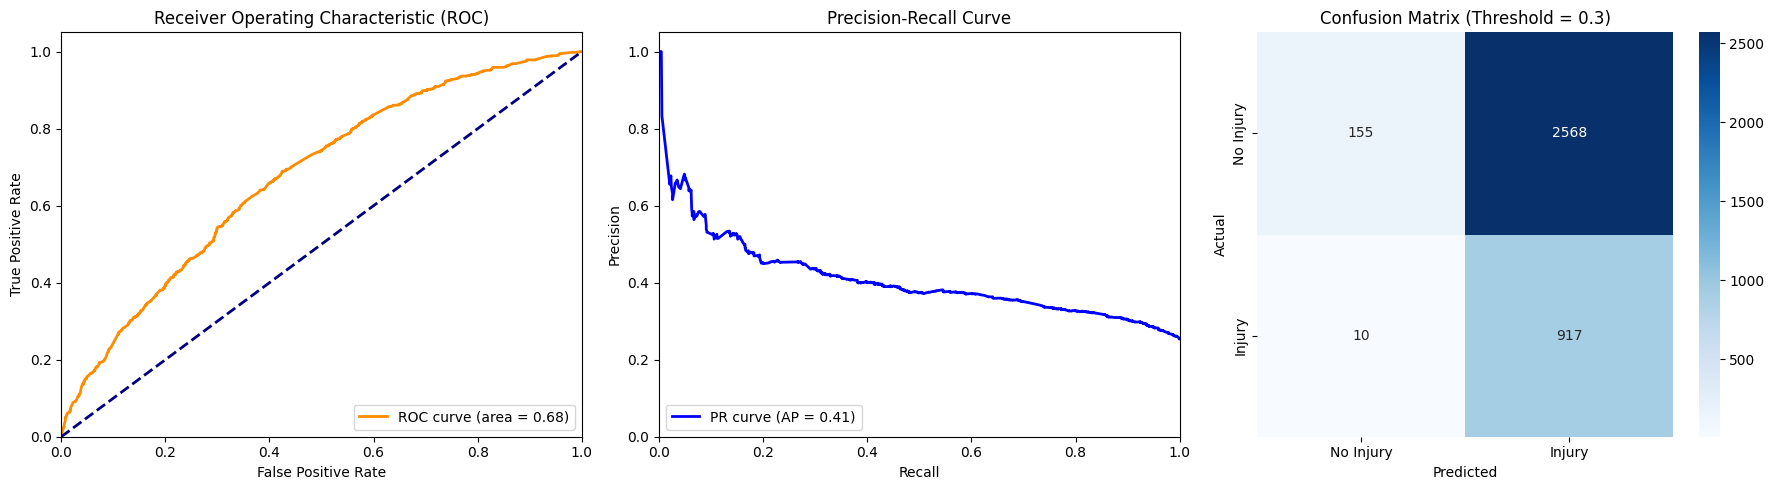

In [9]:
# Get predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Print evaluation summary using the evaluate module
evaluate.print_evaluation_summary(y_test, y_pred_proba, threshold=0.3)

# Plot graphs
evaluate.plot_curves_and_matrix(y_test, y_pred_proba, threshold=0.3)

## 08. SHAP Explainability
SHAP explains how each feature impacts the prediction, shifting it from a black box to a transparent sports-science decision support tool.

Background dataset has 10950 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=10950 when initializing the masker.


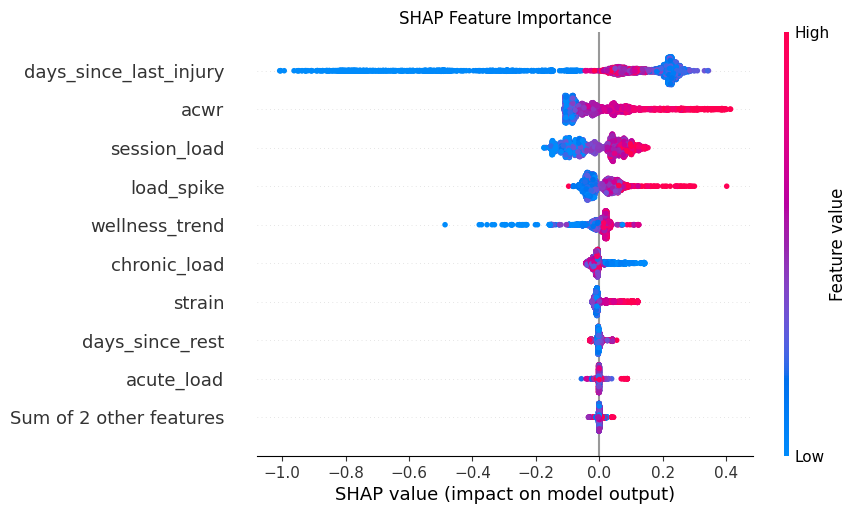

In [10]:
# Set up SHAP Explainer
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Plot beeswarm
plt.title("SHAP Feature Importance")
shap.plots.beeswarm(shap_values, max_display=10, show=True)

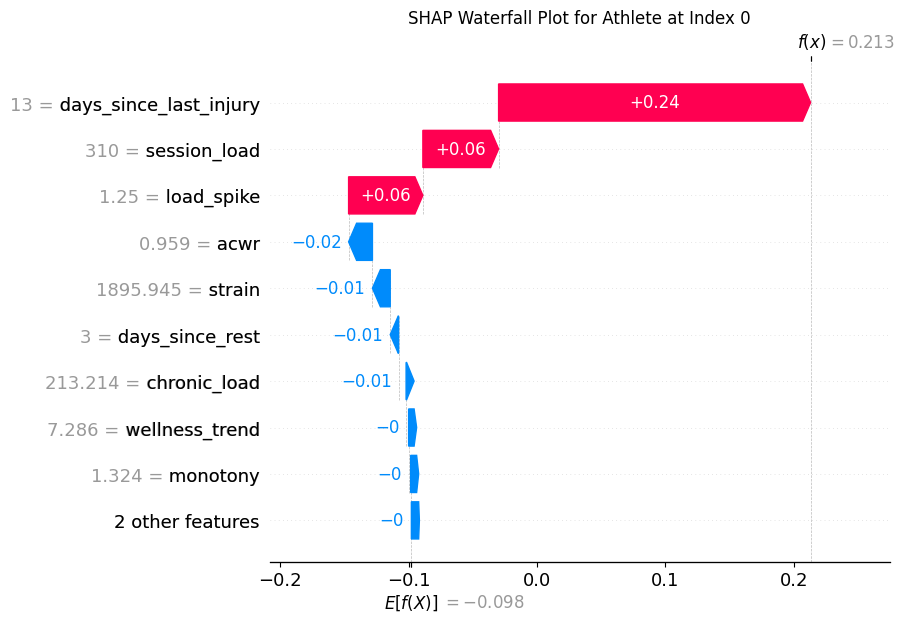

In [11]:
# Plot waterfall plot for a single high-risk instance
high_risk_indices = np.where(y_pred_proba > 0.5)[0]
if len(high_risk_indices) > 0:
    idx = high_risk_indices[0]
    plt.title(f"SHAP Waterfall Plot for Athlete at Index {idx}")
    shap.plots.waterfall(shap_values[idx])
else:
    print("No high risk predictions found to plot waterfall.")

## 09. Exporting the Model
Export the trained model and feature schema so they can be loaded by the backend API.

In [12]:
# Save model file
os.makedirs('../models', exist_ok=True)
model_path = '../models/injury_model.pkl'
joblib.dump(model, model_path)
print(f"Saved trained model to: {model_path}")

# Save feature column order
feature_columns_path = '../models/feature_columns.json'
with open(feature_columns_path, 'w') as f:
    json.dump(feature_cols, f)
print(f"Saved feature columns sequence to: {feature_columns_path}")

Saved trained model to: ../models/injury_model.pkl
Saved feature columns sequence to: ../models/feature_columns.json


## 10. Limitations & Next Steps
1. **Limited Historical Context:** The current model evaluates a small set of daily sessions. Long-term trends can be enhanced with more training data.
2. **Real-time Re-training:** Setting up cron jobs to periodically pull new data from backend production databases (e.g. Supabase) and run retraining pipelines.
3. **Dynamic Features:** Incorporating heart rate variability (HRV), sleep score deviations, and travel metrics for higher accuracy.